IRIS DATASET
------------
Number of samples: 150
Number of features: 4
Feature names: ['sepal length', 'sepal width', 'petal length', 'petal width']
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

First 5 records:
   sepal length  sepal width  petal length  petal width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]

Accuracy: 83.33 %

Confusion Matrix:
[[50  0  0]
 [ 0 39 11]
 [ 0 14 36]]

Silhouette Score: 0.459


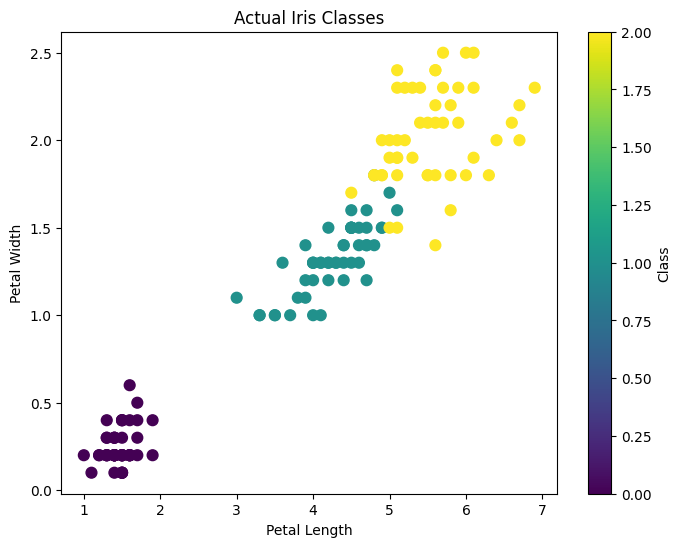

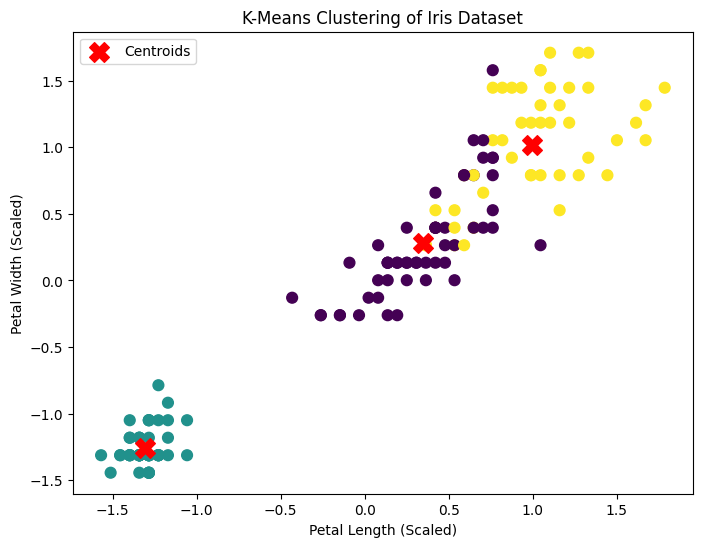

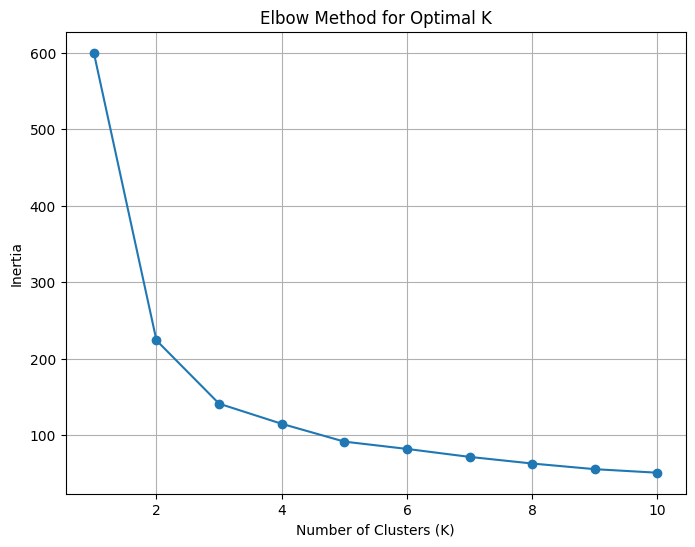


FINAL RESULT
Algorithm : K-Means Clustering
Number of Clusters : 3
Accuracy : 83.33 %
Silhouette Score : 0.459


In [2]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score
from scipy.stats import mode

iris = fetch_ucirepo(id=53)

X = iris.data.features
y = iris.data.targets.iloc[:, 0]

print("IRIS DATASET")
print("------------")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Feature names:", list(X.columns))
print("Classes:", y.unique())

print("\nFirst 5 records:")
print(X.head())

y = y.map({
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

mapped_labels = np.zeros_like(clusters)

for i in range(3):
    mask = clusters == i
    mapped_labels[mask] = mode(y[mask], keepdims=True).mode[0]

accuracy = accuracy_score(y, mapped_labels)

print("\nCluster Labels:")
print(clusters)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

cm = confusion_matrix(y, mapped_labels)

print("\nConfusion Matrix:")
print(cm)

silhouette = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", round(silhouette, 3))

plt.figure(figsize=(8, 6))
plt.scatter(
    X.iloc[:, 2],
    X.iloc[:, 3],
    c=y,
    cmap="viridis",
    s=60
)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Actual Iris Classes")
plt.colorbar(label="Class")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=clusters,
    cmap="viridis",
    s=60
)

plt.scatter(
    kmeans.cluster_centers_[:, 2],
    kmeans.cluster_centers_[:, 3],
    c="red",
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("K-Means Clustering of Iris Dataset")
plt.legend()
plt.show()

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid()
plt.show()

print("\n==============================")
print("FINAL RESULT")
print("==============================")
print("Algorithm : K-Means Clustering")
print("Number of Clusters : 3")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Silhouette Score :", round(silhouette, 3))
print("==============================")